In [46]:
from qiskit import *
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram 
import matplotlib.pyplot as plt
import numpy as np

In [47]:
# Define the oracle circuit
# Marks the |11⟩ state by flipping its phase using a CZ (Controlled-Z) gate
oracle = QuantumCircuit(2, name='oracle')
oracle.cz(0, 1)     # # CZ: flips the phase of |11⟩
oracle.to_gate()
oracle.draw()

q_0: ─■─
      │ 
q_1: ─■─

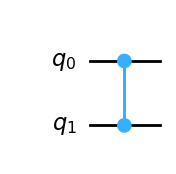

In [48]:
oracle.draw(output='mpl')

In [49]:
# PARTIAL CIRCUIT (no reflection, just to inspect the statevector)
# H creates a uniform superposition, then the oracle is applied
backend = AerSimulator(method='statevector')
grover_circ = QuantumCircuit(2, 2)
grover_circ.h([0, 1])                       # Superposition: |00⟩ + |01⟩ + |10⟩ + |11⟩
grover_circ.append(oracle, [0, 1])          # Apply the oracle (marks |11⟩)
grover_circ.draw()

┌───┐┌─────────┐
q_0: ┤ H ├┤0        ├
     ├───┤│  oracle │
q_1: ┤ H ├┤1        ├
     └───┘└─────────┘
c: 2/════════════════

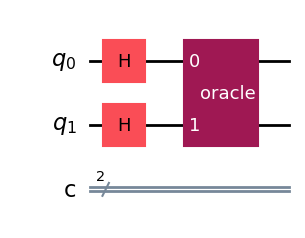

In [50]:
grover_circ.draw(output='mpl')

In [51]:
# Save the statevector before measuring
grover_circ.save_statevector()
transpiled_circ = transpile(grover_circ, backend)
job = backend.run(transpiled_circ)
result = job.result()

In [52]:
# Display the amplitudes rounded to 2 decimal places
sv = result.get_statevector()
# The last 5 lines of code and the backend declaration can be replaced with:
# sv = Statevector(grover_circ)
# (Only if we don't need to measure, but in that case we can call Statevector() before measuring and then the rest of the lines)
np.around(sv, 2)    # → [ 0.5, 0.5, 0.5, -0.5 ] (|11⟩ has negative phase)

array([ 0.5+0.j,  0.5+0.j,  0.5+0.j, -0.5+0.j])

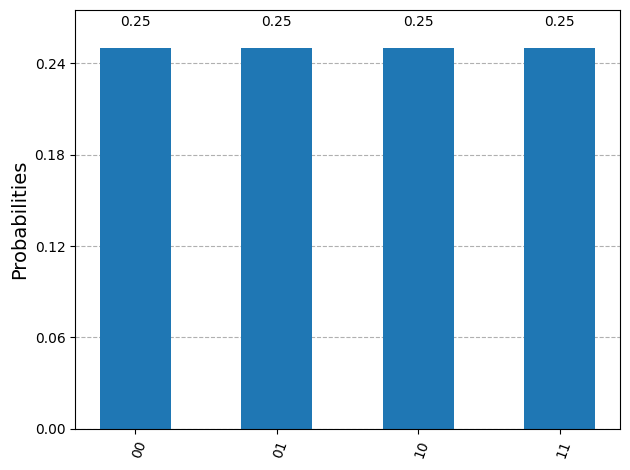

In [53]:
# Plot the probabilities from the statevector
probs = sv.probabilities_dict()
fig = plot_histogram(probs)
fig.axes[0].set_ylabel('Probabilities')
fig

In [54]:
# REFLECTION (Grover diffusion operator)
# Amplifies the amplitude of the marked state
reflection = QuantumCircuit(2, name='reflection')
reflection.h([0, 1])    # Step 1: change of basis
reflection.z([0, 1])    # Step 2: flip the phase of all states except |00⟩
reflection.cz(0, 1)     # Step 3: mark |00⟩ with CZ
reflection.h([0, 1])    # Step 4: return to the computational basis
reflection.to_gate()
reflection.draw()

┌───┐┌───┐   ┌───┐
q_0: ┤ H ├┤ Z ├─■─┤ H ├
     ├───┤├───┤ │ ├───┤
q_1: ┤ H ├┤ Z ├─■─┤ H ├
     └───┘└───┘   └───┘

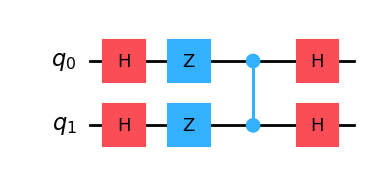

In [55]:
reflection.draw(output='mpl')

In [56]:
# FULL GROVER CIRCUIT
backend = AerSimulator()                    # qasm-style simulator (counts)
grover_circ = QuantumCircuit(2, 2)
grover_circ.h([0, 1])                       # Step 1: create uniform superposition
grover_circ.append(oracle, [0, 1])          # Oracle: marks |11⟩
grover_circ.append(reflection, [0, 1])      # Reflection: amplifies |11⟩
grover_circ.measure([0, 1], [0, 1])         # Measure all qubits
grover_circ.draw()

┌───┐┌─────────┐┌─────────────┐┌─┐   
q_0: ┤ H ├┤0        ├┤0            ├┤M├───
     ├───┤│  oracle ││  reflection │└╥┘┌─┐
q_1: ┤ H ├┤1        ├┤1            ├─╫─┤M├
     └───┘└─────────┘└─────────────┘ ║ └╥┘
c: 2/════════════════════════════════╩══╩═
                                     0  1

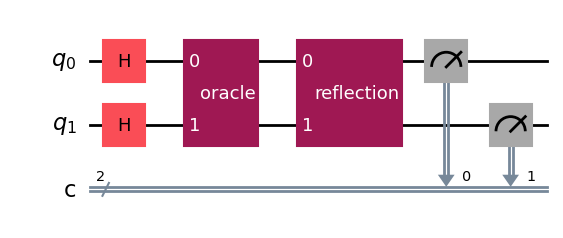

In [57]:
grover_circ.draw(output='mpl')

In [58]:
# Run the circuit and get measurement counts
transpiled = transpile(grover_circ, backend)
job = backend.run(transpiled, shots=1)
result = job.result()
result.get_counts()     # → {'11': 1} — finds the solution in a single shot

{'11': 1}